# Debug Training Process - Step-by-Step Analysis

This notebook walks through each step of the PQC training process with detailed logging to diagnose why the model isn't learning.

## Key Questions We'll Answer:
1. Are parameters initialized correctly?
2. Is the circuit structure correct?
3. Do parameter changes affect the output?
4. Are gradients flowing properly?
5. Is the optimizer updating parameters?
6. Why is the loss not decreasing?

In [1]:
# Import required libraries
import jax
import jax.numpy as jnp
import optax
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Set random seeds
SEED = 42
np.random.seed(SEED)

print(f"JAX version: {jax.__version__}")
print(f"Using device: {jax.devices()[0]}")

JAX version: 0.6.0
Using device: TFRT_CPU_0


## Step 1: Generate Circuit and Initialize Model

First, let's create a small test case to make debugging easier.

In [2]:
from pqcqec.circuits.generate import generate_random_circuit
from pqcqec.circuits.modify import tokenize_qiskit_circuit
from pqcqec.models.pqc_models import LELZZInterleavedQuaternionCustomStatevecModel
from pqcqec.simulate.simulate import get_input_data

# Configuration (small for debugging)
num_qubits = 3
num_gates = 5
gate_blocks = 5
pqc_blocks = 1
num_train_data = 10
batch_size = 2

print(f"Configuration:")
print(f"  Qubits: {num_qubits}")
print(f"  Gates: {num_gates}")
print(f"  Gate blocks: {gate_blocks}")
print(f"  PQC blocks: {pqc_blocks}")
print(f"  Training samples: {num_train_data}")
print(f"  Batch size: {batch_size}")

Configuration:
  Qubits: 3
  Gates: 5
  Gate blocks: 5
  PQC blocks: 1
  Training samples: 10
  Batch size: 2


In [3]:
# Generate random circuit
qiskit_circuit = generate_random_circuit(
    num_qubits=num_qubits,
    num_gates=num_gates,
    seed=SEED
)

print(f"Generated base circuit with {len(qiskit_circuit)} gates")
print(f"\nCircuit operations:")
for i, instr in enumerate(qiskit_circuit.data):
    print(f"  {i}: {instr.operation.name} on qubits {[q._index for q in instr.qubits]}")

Generated base circuit with 5 gates

Circuit operations:
  0: cx on qubits [2, 0]
  1: x on qubits [2]
  2: z on qubits [1]
  3: z on qubits [0]
  4: cx on qubits [0, 2]


In [4]:
# Add uncomputation (U U†)
qiskit_adjoint = qiskit_circuit.inverse()
qiskit_uncomp = qiskit_circuit.compose(qiskit_adjoint)
circuit_ops = tokenize_qiskit_circuit(qiskit_uncomp)

print(f"\nWith uncomputation: {len(circuit_ops)} operations")
print(f"Expected: {num_gates * 2} operations (circuit + adjoint)")
print(f"\nFirst 5 operations:")
for i, op in enumerate(circuit_ops[:5]):
    print(f"  {i}: {op}")


With uncomputation: 10 operations
Expected: 10 operations (circuit + adjoint)

First 5 operations:
  0: ('cx', [2, 0], [])
  1: ('x', [2], [])
  2: ('z', [1], [])
  3: ('z', [0], [])
  4: ('cx', [0, 2], [])


## Step 2: Create Noise Model and Initialize PQC

In [5]:
# Create noise arrays (fixed during training)
x_noise = np.random.uniform(0.08, 0.12, (len(circuit_ops),)).astype(np.float32)
z_noise = np.random.uniform(0.08, 0.12, (len(circuit_ops),)).astype(np.float32)

print(f"Noise arrays:")
print(f"  X-noise: min={x_noise.min():.4f}, max={x_noise.max():.4f}, mean={x_noise.mean():.4f}")
print(f"  Z-noise: min={z_noise.min():.4f}, max={z_noise.max():.4f}, mean={z_noise.mean():.4f}")

Noise arrays:
  X-noise: min=0.0823, max=0.1180, mean=0.1008
  Z-noise: min=0.0808, max=0.1188, mean=0.0958


In [6]:
# Initialize model
model = LELZZInterleavedQuaternionCustomStatevecModel(
    base_circuit_ops=circuit_ops,
    num_qubits=num_qubits,
    x_noise=x_noise,
    z_noise=z_noise,
    pqc_blocks=pqc_blocks,
    gate_blocks=gate_blocks,
    seed=SEED
)

print(f"Model initialized successfully")

Model initialized successfully


## Step 3: Inspect Initial Parameters

In [7]:
# Get initial parameters
initial_params = model.get_model_params()

print(f"Initial parameters:")
print(f"\nPre-quaternions:")
print(f"  Shape: {initial_params['pre_quaternions'].shape}")
print(f"  Min: {initial_params['pre_quaternions'].min():.6f}")
print(f"  Max: {initial_params['pre_quaternions'].max():.6f}")
print(f"  Mean: {initial_params['pre_quaternions'].mean():.6f}")
print(f"  Values:\n{initial_params['pre_quaternions']}")

print(f"\nTheta_zz:")
print(f"  Shape: {initial_params['theta_zz'].shape}")
print(f"  Values: {initial_params['theta_zz']}")
print(f"  ⚠️ All zeros? {jnp.allclose(initial_params['theta_zz'], 0.0)}")

print(f"\nPost-quaternions:")
print(f"  Shape: {initial_params['post_quaternions'].shape}")
print(f"  Min: {initial_params['post_quaternions'].min():.6f}")
print(f"  Max: {initial_params['post_quaternions'].max():.6f}")
print(f"  Mean: {initial_params['post_quaternions'].mean():.6f}")

# Count total parameters
total_params = (initial_params['pre_quaternions'].size + 
                initial_params['theta_zz'].size + 
                initial_params['post_quaternions'].size)
print(f"\nTotal trainable parameters: {total_params}")

Initial parameters:

Pre-quaternions:
  Shape: (2, 3, 4)
  Min: -0.137709
  Max: 0.991139
  Mean: 0.282367
  Values:
[[[ 9.4976902e-01  1.7205399e-02 -1.1020955e-01  2.9239807e-01]
  [ 9.4396222e-01  2.5381464e-01  1.4673841e-01  1.5159589e-01]
  [ 9.8808730e-01  3.9904144e-02 -5.5923760e-02 -1.3770853e-01]]

 [[ 9.8405975e-01  1.6835575e-01  5.7291418e-02  6.5134518e-04]
  [ 9.9113947e-01  1.3183628e-01  1.6088599e-02 -1.6935033e-03]
  [ 9.8710126e-01 -1.3194366e-01  3.6933441e-03  9.0600103e-02]]]

Theta_zz:
  Shape: (3,)
  Values: [0. 0. 0.]
  ⚠️ All zeros? True

Post-quaternions:
  Shape: (2, 3, 4)
  Min: -0.220537
  Max: 0.993360
  Mean: 0.220587

Total trainable parameters: 51


## Step 4: Test Parameter Sensitivity

**Critical Test:** Do parameter changes affect the output?

In [8]:
# Create test input
test_input = get_input_data(num_qubits, 1, seed=SEED)

print(f"Test input shape: {test_input.shape}")
print(f"Test input norm: {jnp.linalg.norm(test_input):.6f}")

# Run with initial parameters
output_initial = model.run_model_batch(
    test_input,
    initial_params['pre_quaternions'],
    initial_params['theta_zz'],
    initial_params['post_quaternions']
)

print(f"\nOutput with initial params:")
print(f"  Shape: {output_initial.shape}")
print(f"  Norm: {jnp.linalg.norm(output_initial):.6f}")
print(f"  Values (first 4): {output_initial[0, :4]}")

Test input shape: (1, 8)
Test input norm: 1.000000

Output with initial params:
  Shape: (1, 8)
  Norm: 0.274527
  Values (first 4): [ 2.1093297e-01+1.7570503e-01j -5.9021113e-06-8.6808932e-06j
 -4.0495033e-06-5.9560562e-06j -5.9021113e-06-8.6808932e-06j]


In [9]:
# Test 1: Change theta_zz to different values
print("=" * 60)
print("Test 1: Theta_ZZ Sensitivity")
print("=" * 60)

theta_test_values = [
    jnp.array([0.0, 0.0, 0.0]),
    jnp.array([0.5, 0.5, 0.5]),
    jnp.array([0.1, 0.3, 0.5]),
    jnp.array([1.0, 1.0, 1.0]),
]

outputs_theta = []
for i, theta in enumerate(theta_test_values):
    output = model.run_model_batch(
        test_input,
        initial_params['pre_quaternions'],
        theta,
        initial_params['post_quaternions']
    )
    outputs_theta.append(output)
    print(f"\ntheta_zz = {theta}")
    print(f"  Output norm: {jnp.linalg.norm(output):.6f}")
    if i > 0:
        diff = jnp.linalg.norm(output - outputs_theta[0])
        print(f"  Difference from baseline: {diff:.6e}")

# Check if outputs are all the same
all_same = all(jnp.allclose(outputs_theta[0], out, atol=1e-10) for out in outputs_theta[1:])
print(f"\n⚠️ All outputs identical? {all_same}")
if all_same:
    print("   ✗ PROBLEM: theta_zz changes don't affect output!")
else:
    print("   ✓ theta_zz changes DO affect output")

Test 1: Theta_ZZ Sensitivity

theta_zz = [0. 0. 0.]
  Output norm: 0.274527

theta_zz = [0.5 0.5 0.5]
  Output norm: 0.274527
  Difference from baseline: 0.000000e+00

theta_zz = [0.1 0.3 0.5]
  Output norm: 0.274527
  Difference from baseline: 0.000000e+00

theta_zz = [1. 1. 1.]
  Output norm: 0.274527
  Difference from baseline: 0.000000e+00

⚠️ All outputs identical? True
   ✗ PROBLEM: theta_zz changes don't affect output!


In [10]:
# Test 2: Change pre-quaternions
print("\n" + "=" * 60)
print("Test 2: Pre-Quaternion Sensitivity")
print("=" * 60)

# Perturb pre-quaternions slightly
pre_quats_perturbed = initial_params['pre_quaternions'] + jax.random.normal(
    jax.random.PRNGKey(123), 
    initial_params['pre_quaternions'].shape
) * 0.1

output_perturbed = model.run_model_batch(
    test_input,
    pre_quats_perturbed,
    initial_params['theta_zz'],
    initial_params['post_quaternions']
)

diff_pre = jnp.linalg.norm(output_perturbed - output_initial)
print(f"\nDifference from initial: {diff_pre:.6e}")

if diff_pre < 1e-10:
    print("✗ PROBLEM: Pre-quaternion changes don't affect output!")
else:
    print("✓ Pre-quaternions DO affect output")


Test 2: Pre-Quaternion Sensitivity

Difference from initial: 1.664095e-02
✓ Pre-quaternions DO affect output


## Step 5: Test Gradient Flow

**Critical:** Can we compute gradients with respect to all parameters?

In [11]:
from pqcqec.training.jax_loss_functions import jax_fidelity_loss, jax_mse_complex_loss_aligned

print("=" * 60)
print("Testing Gradient Flow")
print("=" * 60)

def compute_loss_and_grads(pre_q, theta, post_q, loss_fn, loss_name):
    """Helper to compute loss and gradients."""
    
    def loss(p_q, t, po_q):
        output = model.run_model_batch(test_input, p_q, t, po_q)
        return loss_fn(test_input, output)
    
    loss_val, grads = jax.value_and_grad(loss, argnums=(0, 1, 2))(
        pre_q, theta, post_q
    )
    
    print(f"\n{loss_name}:")
    print(f"  Loss value: {loss_val:.6f}")
    print(f"  Pre-quaternion gradient norm: {jnp.linalg.norm(grads[0]):.6e}")
    print(f"  Theta_zz gradient norm: {jnp.linalg.norm(grads[1]):.6e}")
    print(f"  Post-quaternion gradient norm: {jnp.linalg.norm(grads[2]):.6e}")
    
    # Check for zeros
    pre_zero = jnp.allclose(grads[0], 0.0, atol=1e-12)
    theta_zero = jnp.allclose(grads[1], 0.0, atol=1e-12)
    post_zero = jnp.allclose(grads[2], 0.0, atol=1e-12)
    
    print(f"  Gradient status:")
    print(f"    Pre-quaternions: {'✗ ZERO' if pre_zero else '✓ Non-zero'}")
    print(f"    Theta_zz: {'✗ ZERO' if theta_zero else '✓ Non-zero'}")
    print(f"    Post-quaternions: {'✗ ZERO' if post_zero else '✓ Non-zero'}")
    
    # Check for NaNs
    has_nan = (jnp.any(jnp.isnan(grads[0])) or 
               jnp.any(jnp.isnan(grads[1])) or 
               jnp.any(jnp.isnan(grads[2])))
    if has_nan:
        print(f"  ⚠️ WARNING: NaN detected in gradients!")
    
    return loss_val, grads

# Test with both loss functions
loss_fid, grads_fid = compute_loss_and_grads(
    initial_params['pre_quaternions'],
    initial_params['theta_zz'],
    initial_params['post_quaternions'],
    jax_fidelity_loss,
    "Fidelity Loss"
)

loss_mse, grads_mse = compute_loss_and_grads(
    initial_params['pre_quaternions'],
    initial_params['theta_zz'],
    initial_params['post_quaternions'],
    jax_mse_complex_loss_aligned,
    "MSE Loss (Phase Aligned)"
)

Testing Gradient Flow

Fidelity Loss:
  Loss value: 0.960991
  Pre-quaternion gradient norm: 7.329974e-06
  Theta_zz gradient norm: 0.000000e+00
  Post-quaternion gradient norm: 1.246278e-05
  Gradient status:
    Pre-quaternions: ✓ Non-zero
    Theta_zz: ✗ ZERO
    Post-quaternions: ✓ Non-zero

MSE Loss (Phase Aligned):
  Loss value: 0.200623
  Pre-quaternion gradient norm: 4.648807e-06
  Theta_zz gradient norm: 0.000000e+00
  Post-quaternion gradient norm: 7.886837e-06
  Gradient status:
    Pre-quaternions: ✓ Non-zero
    Theta_zz: ✗ ZERO
    Post-quaternions: ✓ Non-zero


## Step 6: Test Gradient Descent Step

Manually apply one gradient descent step and check if loss decreases.

In [12]:
print("=" * 60)
print("Testing Manual Gradient Descent Step")
print("=" * 60)

# Use MSE loss (better gradients)
learning_rate = 0.01

# Apply gradient descent
new_pre = initial_params['pre_quaternions'] - learning_rate * grads_mse[0]
new_theta = initial_params['theta_zz'] - learning_rate * grads_mse[1]
new_post = initial_params['post_quaternions'] - learning_rate * grads_mse[2]

print(f"\nLearning rate: {learning_rate}")
print(f"\nParameter changes:")
print(f"  Pre-quaternions: {jnp.linalg.norm(new_pre - initial_params['pre_quaternions']):.6e}")
print(f"  Theta_zz: {jnp.linalg.norm(new_theta - initial_params['theta_zz']):.6e}")
print(f"  Post-quaternions: {jnp.linalg.norm(new_post - initial_params['post_quaternions']):.6e}")

# Compute new loss
output_new = model.run_model_batch(test_input, new_pre, new_theta, new_post)
new_loss = jax_mse_complex_loss_aligned(test_input, output_new)

loss_change = new_loss - loss_mse

print(f"\nLoss change:")
print(f"  Old loss: {loss_mse:.6f}")
print(f"  New loss: {new_loss:.6f}")
print(f"  Change: {loss_change:.6e} ({'✓ DECREASED' if loss_change < 0 else '✗ INCREASED'})")

if abs(loss_change) < 1e-10:
    print(f"\n⚠️ WARNING: Loss didn't change at all!")
    print(f"   This suggests gradients aren't affecting the output.")

Testing Manual Gradient Descent Step

Learning rate: 0.01

Parameter changes:
  Pre-quaternions: 4.615688e-08
  Theta_zz: 0.000000e+00
  Post-quaternions: 7.554628e-08

Loss change:
  Old loss: 0.200623
  New loss: 0.200623
  Change: 0.000000e+00 (✗ INCREASED)

⚠️ WARNING: Loss didn't change at all!
   This suggests gradients aren't affecting the output.


## Step 7: Initialize Optimizer and Run Training Loop

In [13]:
# Generate training data
train_input_data = get_input_data(num_qubits, num_train_data, seed=SEED)
print(f"Training data shape: {train_input_data.shape}")

# Simple optimizer setup
learning_rate_opt = 1e-3
optimizer = optax.adam(learning_rate_opt)

# Initialize optimizer state
opt_state = optimizer.init((
    initial_params['pre_quaternions'],
    initial_params['theta_zz'],
    initial_params['post_quaternions']
))

print(f"\nOptimizer: Adam")
print(f"Learning rate: {learning_rate_opt}")

Training data shape: (10, 8)

Optimizer: Adam
Learning rate: 0.001


In [14]:
# Training loop with detailed logging
print("=" * 60)
print("Training Loop")
print("=" * 60)

num_steps = 5  # Just a few steps for debugging

# Current parameters
current_pre = initial_params['pre_quaternions']
current_theta = initial_params['theta_zz']
current_post = initial_params['post_quaternions']

losses = []
grad_norms_pre = []
grad_norms_theta = []
grad_norms_post = []
param_changes = []

@jax.jit
def train_step(pre_q, theta, post_q, opt_state, batch_data):
    """Single training step."""
    
    def loss_fn(p_q, t, po_q):
        output = model.run_model_batch(batch_data, p_q, t, po_q)
        return jax_mse_complex_loss_aligned(batch_data, output)
    
    loss, grads = jax.value_and_grad(loss_fn, argnums=(0, 1, 2))(
        pre_q, theta, post_q
    )
    
    # Sanitize gradients
    grads = jax.tree.map(
        lambda g: jnp.nan_to_num(g, nan=0.0, posinf=0.0, neginf=0.0), 
        grads
    )
    
    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, (pre_q, theta, post_q))
    new_pre, new_theta, new_post = optax.apply_updates((pre_q, theta, post_q), updates)
    
    # Keep params finite
    new_pre = jnp.nan_to_num(new_pre, nan=0.0, posinf=0.0, neginf=0.0)
    new_theta = jnp.nan_to_num(new_theta, nan=0.0, posinf=0.0, neginf=0.0)
    new_post = jnp.nan_to_num(new_post, nan=0.0, posinf=0.0, neginf=0.0)
    
    return new_pre, new_theta, new_post, new_opt_state, loss, grads

print(f"\nRunning {num_steps} training steps...\n")

for step in range(num_steps):
    # Get batch
    start_idx = (step * batch_size) % num_train_data
    end_idx = start_idx + batch_size
    batch_data = train_input_data[start_idx:end_idx]
    
    # Training step
    new_pre, new_theta, new_post, opt_state, loss, grads = train_step(
        current_pre, current_theta, current_post, opt_state, batch_data
    )
    
    # Compute metrics
    grad_norm_pre = float(jnp.linalg.norm(grads[0]))
    grad_norm_theta = float(jnp.linalg.norm(grads[1]))
    grad_norm_post = float(jnp.linalg.norm(grads[2]))
    
    param_change = float(
        jnp.linalg.norm(new_pre - current_pre) +
        jnp.linalg.norm(new_theta - current_theta) +
        jnp.linalg.norm(new_post - current_post)
    )
    
    # Store metrics
    losses.append(float(loss))
    grad_norms_pre.append(grad_norm_pre)
    grad_norms_theta.append(grad_norm_theta)
    grad_norms_post.append(grad_norm_post)
    param_changes.append(param_change)
    
    # Log
    print(f"Step {step + 1}/{num_steps}:")
    print(f"  Loss: {loss:.6f}")
    print(f"  Gradient norms: pre={grad_norm_pre:.2e}, theta={grad_norm_theta:.2e}, post={grad_norm_post:.2e}")
    print(f"  Parameter change: {param_change:.2e}")
    
    # Check for issues
    if grad_norm_theta == 0:
        print(f"  ⚠️ theta_zz gradient is ZERO")
    if param_change < 1e-10:
        print(f"  ⚠️ Parameters not changing")
    
    # Update current parameters
    current_pre = new_pre
    current_theta = new_theta
    current_post = new_post
    print()

Training Loop

Running 5 training steps...

Step 1/5:
  Loss: 0.107222
  Gradient norms: pre=2.37e-05, theta=0.00e+00, post=3.52e-05
  Parameter change: 8.67e-03
  ⚠️ theta_zz gradient is ZERO

Step 2/5:
  Loss: 0.110222
  Gradient norms: pre=3.27e-06, theta=0.00e+00, post=4.72e-06
  Parameter change: 6.53e-03
  ⚠️ theta_zz gradient is ZERO

Step 3/5:
  Loss: 0.115749
  Gradient norms: pre=7.25e-06, theta=0.00e+00, post=1.05e-05
  Parameter change: 3.26e-03
  ⚠️ theta_zz gradient is ZERO

Step 4/5:
  Loss: 0.098731
  Gradient norms: pre=1.18e-06, theta=0.00e+00, post=2.48e-06
  Parameter change: 3.57e-03
  ⚠️ theta_zz gradient is ZERO

Step 5/5:
  Loss: 0.092150
  Gradient norms: pre=1.91e-05, theta=0.00e+00, post=2.98e-05
  Parameter change: 4.99e-03
  ⚠️ theta_zz gradient is ZERO



## Step 8: Visualize Training Metrics

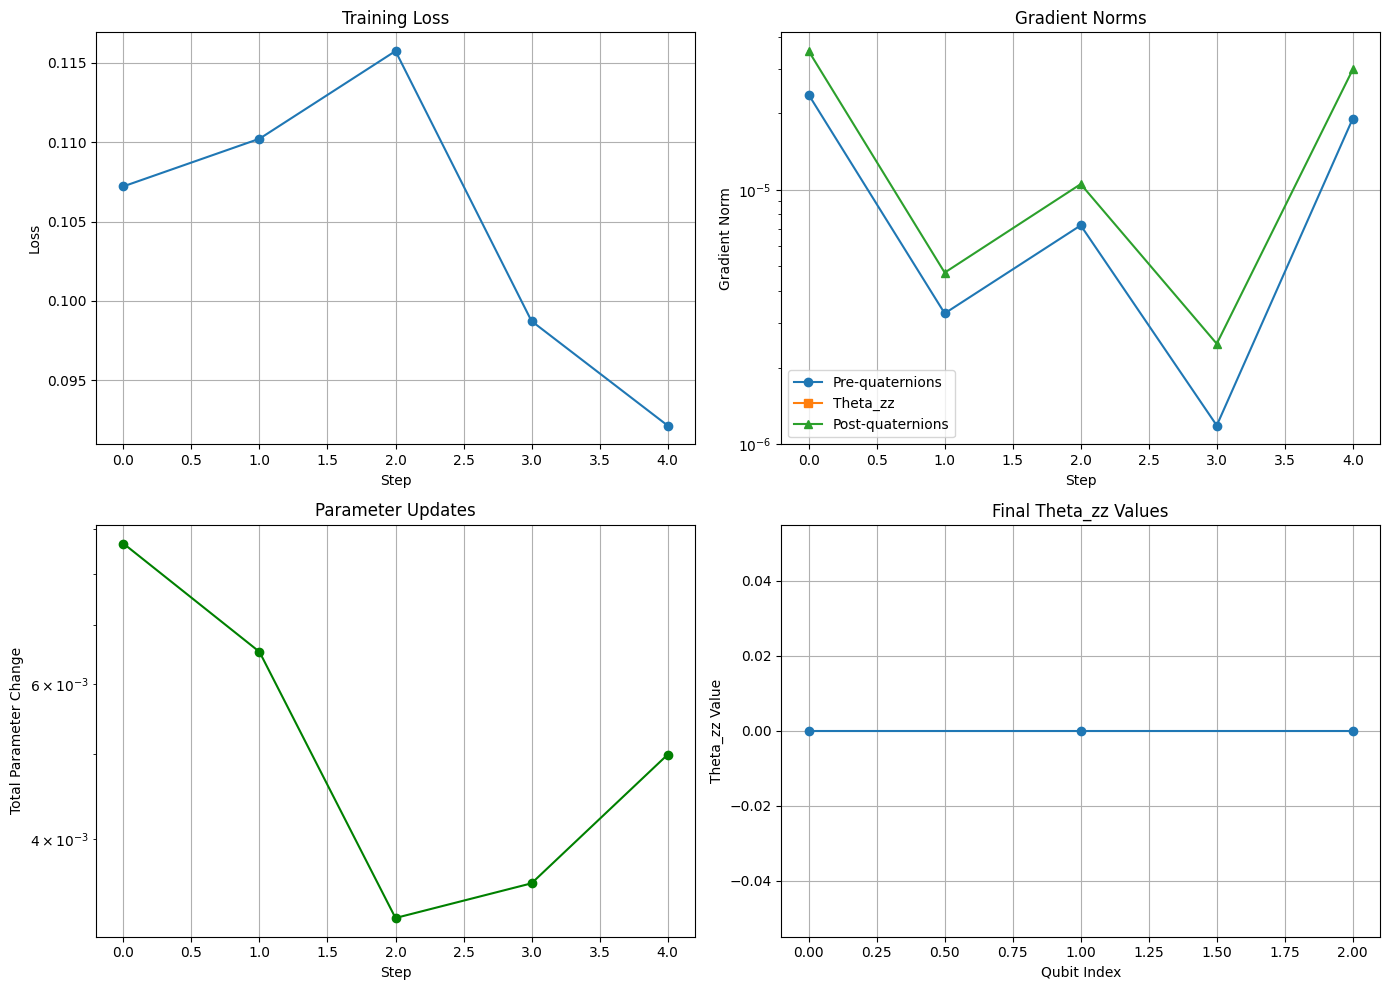


Final theta_zz values: [0. 0. 0.]


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(losses, marker='o')
axes[0, 0].set_xlabel('Step')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].grid(True)

# Gradient norms
axes[0, 1].plot(grad_norms_pre, marker='o', label='Pre-quaternions')
axes[0, 1].plot(grad_norms_theta, marker='s', label='Theta_zz')
axes[0, 1].plot(grad_norms_post, marker='^', label='Post-quaternions')
axes[0, 1].set_xlabel('Step')
axes[0, 1].set_ylabel('Gradient Norm')
axes[0, 1].set_title('Gradient Norms')
axes[0, 1].set_yscale('log')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Parameter changes
axes[1, 0].plot(param_changes, marker='o', color='green')
axes[1, 0].set_xlabel('Step')
axes[1, 0].set_ylabel('Total Parameter Change')
axes[1, 0].set_title('Parameter Updates')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True)

# Theta_zz evolution
axes[1, 1].plot(current_theta, marker='o')
axes[1, 1].set_xlabel('Qubit Index')
axes[1, 1].set_ylabel('Theta_zz Value')
axes[1, 1].set_title('Final Theta_zz Values')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

print(f"\nFinal theta_zz values: {current_theta}")

## Step 9: Diagnosis Summary

In [16]:
print("=" * 60)
print("DIAGNOSIS SUMMARY")
print("=" * 60)

# Check for common issues
issues = []

# Issue 1: theta_zz gradients are zero
if all(g == 0 for g in grad_norms_theta):
    issues.append(
        "✗ theta_zz gradients are ZERO throughout training\n"
        "  → The ZZ entangling layer is not affecting the output\n"
        "  → This is the PRIMARY issue preventing learning"
    )

# Issue 2: Loss not decreasing
if len(losses) > 1 and losses[-1] >= losses[0] * 0.99:
    issues.append(
        "✗ Loss is NOT decreasing\n"
        "  → Gradient descent is not working\n"
        f"  → Initial loss: {losses[0]:.6f}, Final loss: {losses[-1]:.6f}"
    )

# Issue 3: Gradients too small
avg_grad_norm = np.mean(grad_norms_pre + grad_norms_post)
if avg_grad_norm < 1e-6:
    issues.append(
        f"⚠️ Gradients are very small (avg: {avg_grad_norm:.2e})\n"
        "  → This makes learning extremely slow\n"
        "  → Consider: larger learning rate, different loss function, or better initialization"
    )

# Issue 4: Parameters not changing
avg_param_change = np.mean(param_changes)
if avg_param_change < 1e-8:
    issues.append(
        f"✗ Parameters barely changing (avg: {avg_param_change:.2e})\n"
        "  → Learning rate might be too small\n"
        "  → Or gradients are not flowing properly"
    )

if issues:
    print("\n🔴 CRITICAL ISSUES DETECTED:\n")
    for i, issue in enumerate(issues, 1):
        print(f"{i}. {issue}\n")
else:
    print("\n✓ No major issues detected in this small test.")
    print("  The model should be able to train properly.")

print("\n" + "=" * 60)
print("RECOMMENDATIONS")
print("=" * 60)
print(
    "\n1. **Initialize theta_zz with random non-zero values**\n"
    "   Current: [0, 0, 0] → Suggested: random in [-0.5, 0.5]\n\n"
    "2. **Increase batch size** from 1 to 32-64\n\n"
    "3. **Use MSE loss** instead of fidelity loss (better gradients)\n\n"
    "4. **Increase learning rate** to 1e-2 or 1e-3\n\n"
    "5. **Train for more epochs** (10-20 instead of 2)\n\n"
    "6. **Debug why ZZ layer has no effect** on the circuit\n"
)

DIAGNOSIS SUMMARY

🔴 CRITICAL ISSUES DETECTED:

1. ✗ theta_zz gradients are ZERO throughout training
  → The ZZ entangling layer is not affecting the output
  → This is the PRIMARY issue preventing learning


RECOMMENDATIONS

1. **Initialize theta_zz with random non-zero values**
   Current: [0, 0, 0] → Suggested: random in [-0.5, 0.5]

2. **Increase batch size** from 1 to 32-64

3. **Use MSE loss** instead of fidelity loss (better gradients)

4. **Increase learning rate** to 1e-2 or 1e-3

5. **Train for more epochs** (10-20 instead of 2)

6. **Debug why ZZ layer has no effect** on the circuit



## Step 10: Test Proposed Fix - Non-Zero Theta Initialization

In [17]:
print("=" * 60)
print("Testing Fix: Non-Zero Theta_ZZ Initialization")
print("=" * 60)

# Create model with modified initialization
model_fixed = LELZZInterleavedQuaternionCustomStatevecModel(
    base_circuit_ops=circuit_ops,
    num_qubits=num_qubits,
    x_noise=x_noise,
    z_noise=z_noise,
    pqc_blocks=pqc_blocks,
    gate_blocks=gate_blocks,
    seed=SEED + 1  # Different seed
)

# Manually set theta_zz to non-zero values
params_fixed = model_fixed.get_model_params()
theta_zz_init = jax.random.uniform(
    jax.random.PRNGKey(SEED), 
    (num_qubits,), 
    minval=-0.5, 
    maxval=0.5
)

print(f"\nNew theta_zz initialization: {theta_zz_init}")

# Test gradient flow
def loss_fn_fixed(theta):
    output = model_fixed.run_model_batch(
        test_input,
        params_fixed['pre_quaternions'],
        theta,
        params_fixed['post_quaternions']
    )
    return jax_mse_complex_loss_aligned(test_input, output)

loss_fixed = loss_fn_fixed(theta_zz_init)
grad_fixed = jax.grad(loss_fn_fixed)(theta_zz_init)

print(f"\nLoss: {loss_fixed:.6f}")
print(f"Gradient: {grad_fixed}")
print(f"Gradient norm: {jnp.linalg.norm(grad_fixed):.6e}")

if not jnp.allclose(grad_fixed, 0.0):
    print("\n✓ Non-zero initialization helps! Gradients are flowing.")
else:
    print("\n✗ Still no gradients. The issue is deeper.")

Testing Fix: Non-Zero Theta_ZZ Initialization

New theta_zz initialization: [-0.01129043  0.17979717  0.1162715 ]

Loss: 0.200624
Gradient: [0. 0. 0.]
Gradient norm: 0.000000e+00

✗ Still no gradients. The issue is deeper.


## Conclusion

This notebook has walked through the entire training process step-by-step. Review the outputs above to identify where the training breaks down.

**Key areas to check:**
- Step 4: Do parameter changes affect outputs?
- Step 5: Are gradients flowing?
- Step 6: Does gradient descent decrease loss?
- Step 7: Do parameters update during training?
- Step 9: Review the diagnosis summary

**Next steps:**
1. Apply the recommended fixes from Step 9
2. Re-run this notebook with the fixes
3. If issues persist, investigate the circuit construction more deeply